In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

In [2]:
#load data
X1 =np.load('data/f2/initial_inputs.npy')
y1=np.load('data/f2/initial_outputs.npy')# anomaly is negative

In [3]:
# Data verification
print (X1)
print(y1)

[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522]


In [4]:
# Data analysis
y_mean_val = np.mean(y1)
y_val  = np.std(y1)
print(f"Data Standard Deviation is: {y_val:.6f}")
print(f"Data Mean is: {y_mean_val:.6f}")

Data Standard Deviation is: 0.225365
Data Mean is: 0.230674


In [5]:
# The best data
best_f = np.max(y1)
best_idx = np.argmax(y1)
print(f"the best data is: X = {X1[best_idx]}, y_norm = {best_f:.4f}")

the best data is: X = [0.70263656 0.9265642 ], y_norm = 0.6112


In [6]:
# Compute distance for RBF lengthscale
distances = pdist(X1, metric='euclidean') # compute mean distance between data

In [7]:
#GP model
noise_assumption = 1e-2 # moderate noise
rbf_lengthscale  = 0.25*distances.mean()#first attempt with 25% of mean distance

kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model  = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
model.fit(X1, y1)

,kernel,RBF(length_scale=0.128)
,alpha,0.01
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__length_scale,np.float64(0.1277425882333905)
,kernel__length_scale_bounds,'fixed'


In [8]:
# Grid 2D for prediction
n_grid   = 30
x1_range = np.linspace(X1[:,0].min(), X1[:,0].max(), n_grid)
x2_range = np.linspace(X1[:,1].min(), X1[:,1].max(), n_grid)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
x_grid_2d = np.column_stack([xx1.ravel(), xx2.ravel()])

In [9]:
#GP Prediction
post_mean, post_std = model.predict(x_grid_2d, return_std=True)

In [10]:
#EI (adquisition function definition)
def expected_improvement(mean, std, best_f, xi=0.01):
    Z  = (mean - best_f - xi) / (std + 1e-9)
    ei = (mean - best_f - xi) * norm.cdf(Z) + std * norm.pdf(Z)
    ei[std <= 0.0] = 0.0
    return ei

ei_values = expected_improvement(post_mean, post_std, best_f, xi=0.01)

In [11]:
#Calculate the maximum value
idx_next = np.argmax(ei_values)
x_next   = x_grid_2d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]

print(f"proposed query(EI): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}")
print(f"proposed query std (EI): {std_next:.6f}")
print(f"proposed query y_next (EI): {y_next:.6f}")

x_next_out = x_next

proposed query(EI): x1=0.82709499, x2=0.92656420
proposed query std (EI): 0.649174
proposed query y_next (EI): 0.527997


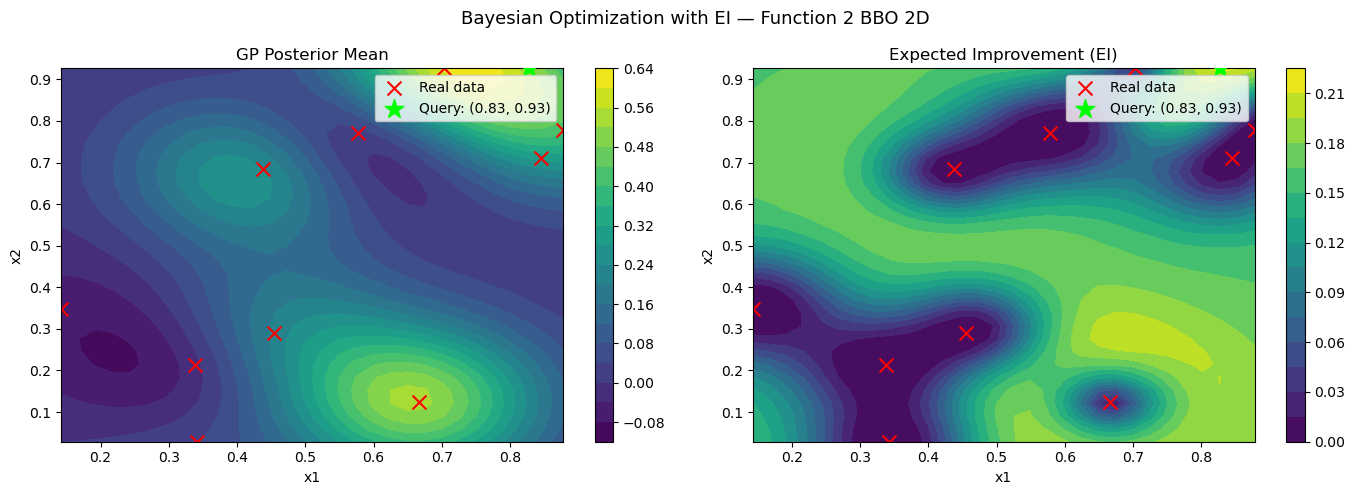

In [12]:
#graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, values, title in zip(axes,
    [post_mean, ei_values],
    ['GP Posterior Mean', 'Expected Improvement (EI)']):

    Z_plot = values.reshape(n_grid, n_grid)
    cp = ax.contourf(xx1, xx2, Z_plot, levels=20, cmap='viridis')
    fig.colorbar(cp, ax=ax)
    ax.scatter(X1[:,0], X1[:,1], c='red', marker='x', s=100, label='Real data')
    ax.scatter(x_next[0], x_next[1], c='lime', marker='*', s=200, zorder=5, label=f'Query: ({x_next[0]:.2f}, {x_next[1]:.2f})')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Bayesian Optimization with EI — Function 2 BBO 2D', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
 ## New adquisition Function UCB (same GP)

In [14]:
# UCB
k = 1.5 #Initial exploration
acquisition = post_mean + k * post_std
idx_next = np.argmax(acquisition)
x_next = x_grid_2d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]
print(f"Proposed query (UCB): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}")
print(f"proposed query std (UCB): {std_next:.6f}")
print(f"proposed query y_next (UCB): {y_next:.6f}")

Proposed query (UCB): x1=0.70035501, x2=0.30734594
proposed query std (UCB): 0.929044
proposed query y_next (UCB): 0.212314


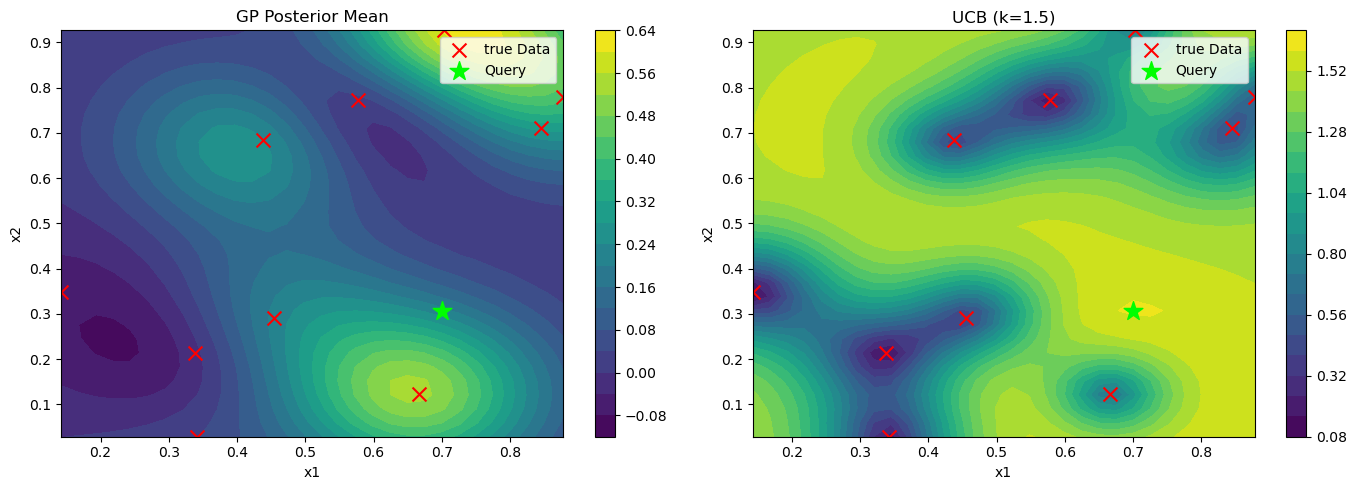

In [15]:
# Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, values, title in zip(axes,
    [post_mean, acquisition],
    ['GP Posterior Mean', f'UCB (k={k})']):
    
    Z = values.reshape(n_grid, n_grid)
    cp = ax.contourf(xx1, xx2, Z, levels=20, cmap='viridis')
    fig.colorbar(cp, ax=ax)
    ax.scatter(X1[:,0], X1[:,1], c='red', marker='x', s=100, label='true Data')
    ax.scatter(x_next[0], x_next[1], c='lime', marker='*', s=200, label='Query')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

In [16]:
# Write output file
import os
folder = 'results'
filename = 'output_F2.txt'
file_path = os.path.join(folder, filename)
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(f"{x_next_out[0]:.6f} {x_next_out[1]:.6f}\n")